# Task 4: Fine-Tuning BERT on IMDB Dataset

In [1]:
!pip install transformers -q

In [2]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import re

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [3]:
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv",
    "IMDB_Dataset.csv"
)
print("Downloaded successfully!")

Downloaded successfully!


In [4]:
df = pd.read_csv('IMDB_Dataset.csv')

df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df = df.dropna(subset=['label'])

def clean(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip().lower()

df['review'] = df['review'].apply(clean)
df = df.sample(5000, random_state=42).reset_index(drop=True)
print('Dataset size:', len(df))

Dataset size: 5000


In [5]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'], df['label'], test_size=0.3, random_state=42
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)
print(f'Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}')

Train: 3500 | Val: 750 | Test: 750


In [6]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class IMDbDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(str(self.texts[idx]), padding='max_length',
                        truncation=True, max_length=128, return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(int(self.labels[idx]))
        }

train_loader = DataLoader(IMDbDataset(train_texts, train_labels), batch_size=16, shuffle=True)
val_loader   = DataLoader(IMDbDataset(val_texts,   val_labels),   batch_size=16)
test_loader  = DataLoader(IMDbDataset(test_texts,  test_labels),  batch_size=16)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
def train_model(model, loader, epochs=2):
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in loader:
            optimizer.zero_grad()
            out = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['labels'].to(device)
            )
            out.loss.backward()
            optimizer.step()
            total_loss += out.loss.item()
        print(f'Epoch {epoch+1} Loss: {total_loss/len(loader):.4f}')

def evaluate(model, loader, title='Results'):
    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for batch in loader:
            out = model(input_ids=batch['input_ids'].to(device),
                        attention_mask=batch['attention_mask'].to(device))
            preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            true.extend(batch['labels'].numpy())

    print(f'\n=== {title} ===')
    print(f'Accuracy : {accuracy_score(true, preds):.4f}')
    print(f'Precision: {precision_score(true, preds):.4f}')
    print(f'Recall   : {recall_score(true, preds):.4f}')
    print(f'F1 Score : {f1_score(true, preds):.4f}')

    sns.heatmap(confusion_matrix(true, preds), annot=True, fmt='d',
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    plt.title(title); plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()

    return accuracy_score(true, preds), f1_score(true, preds)

## Experiment 1: Freeze All BERT Layers (Train Classifier Only)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.6942
Epoch 2 Loss: 0.6897

=== Exp 1: Frozen BERT ===
Accuracy : 0.5333
Precision: 0.5108
Recall   : 0.9093
F1 Score : 0.6542


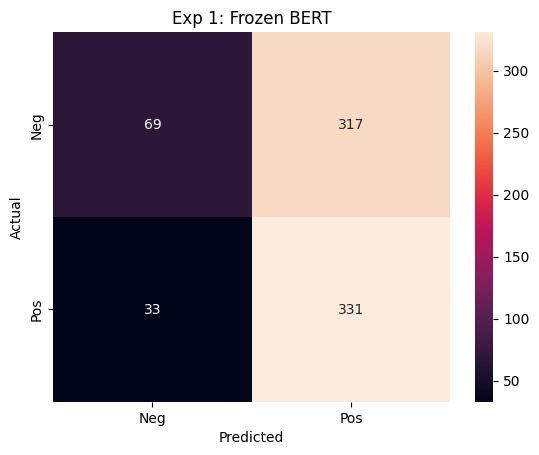

In [8]:
model1 = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

for name, param in model1.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

train_model(model1, train_loader)
acc1, f1_1 = evaluate(model1, test_loader, 'Exp 1: Frozen BERT')

## Experiment 2: Fine-Tune Last 2 Layers + Classifier

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.4815
Epoch 2 Loss: 0.3255

=== Exp 2: Last 2 Layers ===
Accuracy : 0.7987
Precision: 0.7242
Recall   : 0.9451
F1 Score : 0.8200


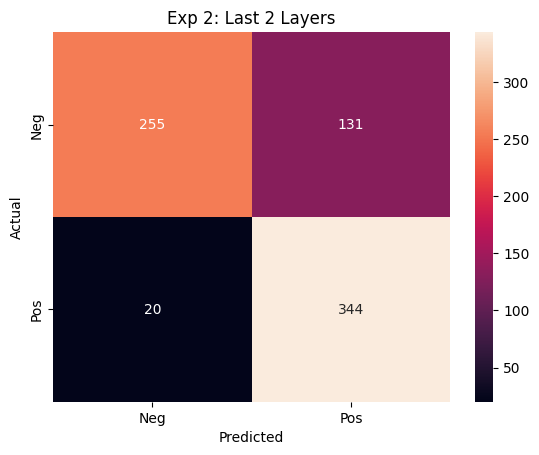

In [9]:
model2 = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

for param in model2.parameters():
    param.requires_grad = False

for name, param in model2.named_parameters():
    if any(x in name for x in ['encoder.layer.10', 'encoder.layer.11', 'pooler', 'classifier']):
        param.requires_grad = True

train_model(model2, train_loader)
acc2, f1_2 = evaluate(model2, test_loader, 'Exp 2: Last 2 Layers')

## Experiment 3: Full Fine-Tuning

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.4522
Epoch 2 Loss: 0.2132

=== Exp 3: Full Fine-Tuning ===
Accuracy : 0.8773
Precision: 0.8469
Recall   : 0.9121
F1 Score : 0.8783


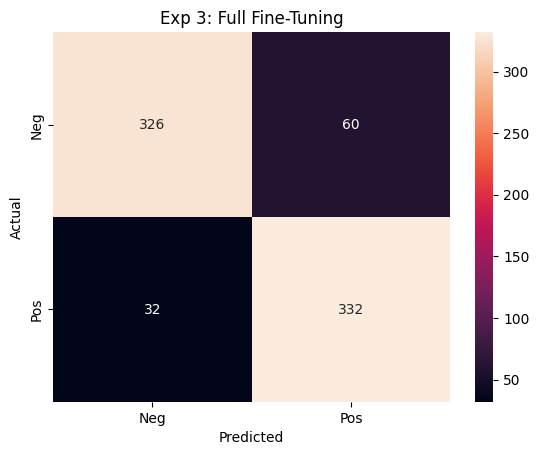

In [10]:
model3 = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

train_model(model3, train_loader)
acc3, f1_3 = evaluate(model3, test_loader, 'Exp 3: Full Fine-Tuning')

## Comparison

          Experiment  Accuracy  F1 Score
   Exp1: Frozen BERT  0.533333  0.654150
 Exp2: Last 2 Layers  0.798667  0.820024
Exp3: Full Fine-Tune  0.877333  0.878307


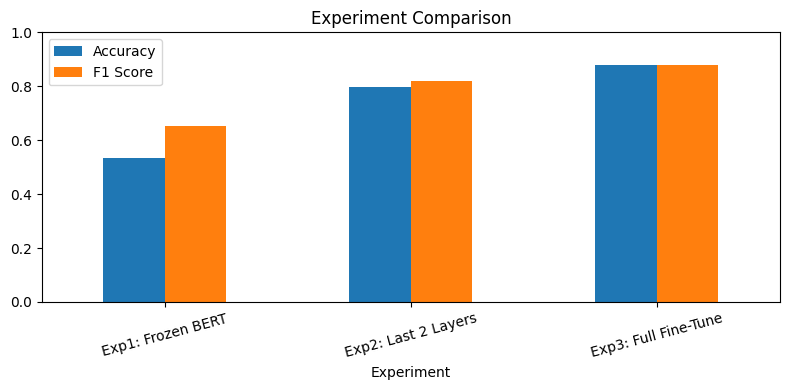

In [11]:
results = pd.DataFrame({
    'Experiment': ['Exp1: Frozen BERT', 'Exp2: Last 2 Layers', 'Exp3: Full Fine-Tune'],
    'Accuracy':   [acc1, acc2, acc3],
    'F1 Score':   [f1_1, f1_2, f1_3]
})
print(results.to_string(index=False))

results.plot(x='Experiment', kind='bar', figsize=(8, 4))
plt.title('Experiment Comparison')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Analysis

- **Exp 1 (Frozen BERT):** Only the classifier head is trained. Fast but weakest performance since BERT weights don't adapt to the task.
- **Exp 2 (Last 2 layers):** Top encoder layers + classifier are updated. Good balance of speed and accuracy.
- **Exp 3 (Full fine-tuning):** All layers updated. Best performance but takes longest to train.

Performance improves as more layers are unfrozen, confirming that task-specific adaptation of BERT's representations is beneficial.